In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('spam.csv',encoding='ISO-8859-1',encoding_errors='ignore')
df['v2'][1]

'Ok lar... Joking wif u oni...'

In [3]:
# df.drop(columns='Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',inplace=True)

In [4]:
#Top 5 Records
df.head(5)

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
#DF Total Record
df.shape[0]

5572

In [6]:
#List Of Cols
df.columns
df.columns=['Target','Text']

In [7]:
#Df Dtypes
df.dtypes

Target    object
Text      object
dtype: object

In [8]:
#Df Complete Info
df.info()  #Summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Target  5572 non-null   object
 1   Text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [9]:
#Check Missing Values
df.isnull().sum()

Target    0
Text      0
dtype: int64

In [10]:
#Check Duplicated Records
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [11]:
#Check Imbalanced Data
df['Target'].value_counts()
#Imbalanced Data

Target
ham     4516
spam     653
Name: count, dtype: int64

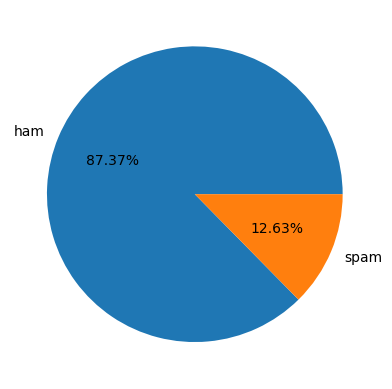

In [13]:
plt.pie(df['Target'].value_counts(),labels=['ham','spam'],autopct='%0.2f%%')
plt.show()

In [14]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['Target']=encoder.fit_transform(df['Target']) #1==Spam and 0==Not Spam

In [15]:
df.head()

,Target,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [16]:
#Num Of Chars
import nltk
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize
df['num_Char']=df['Text'].apply(len)


In [17]:
df.head(2)

,Target,Text,num_Char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29


In [18]:
#Create Custom Features
#Num Of Words
df['Text'].apply(lambda x :nltk.word_tokenize(x))
df['num_words']=df['Text'].apply(lambda x :len(word_tokenize(x)))

In [19]:
#Num Of Sentences 
df['Text'].apply(lambda x :nltk.sent_tokenize(x))
df['num_sents']=df['Text'].apply(lambda x:len(sent_tokenize(x)))

In [20]:
df.head(1)

,Target,Text,num_Char,num_words,num_sents
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2


In [21]:
#Descriptive Statistic
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Target,5169.0,0.126330,0.332253,0.0,0.0,0.0,0.0,1.0
num_Char,5169.0,80.440511,59.468951,2.0,36.0,61.0,119.0,910.0
num_words,5169.0,18.456761,13.325633,1.0,9.0,15.0,26.0,220.0
num_sents,5169.0,1.966531,1.449833,1.0,1.0,1.0,2.0,38.0


<Axes: xlabel='num_Char', ylabel='Count'>

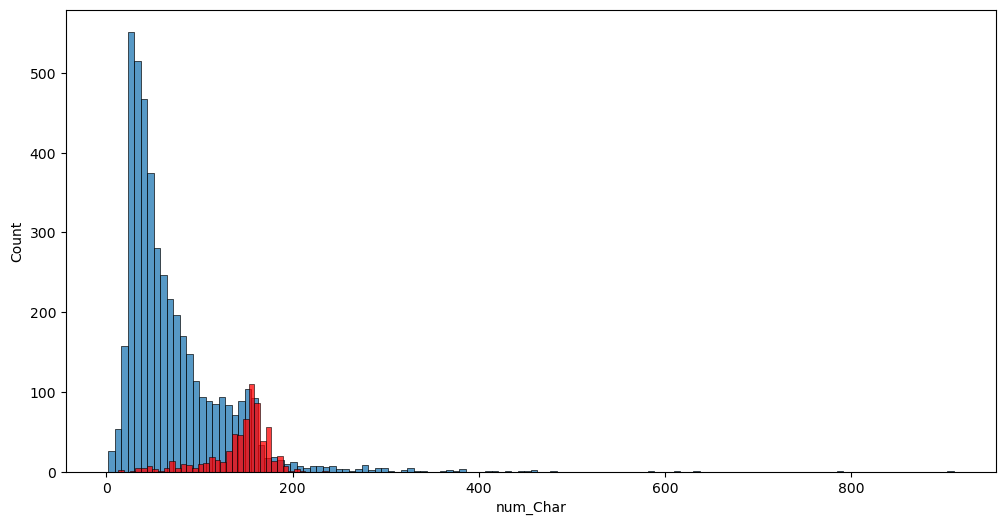

In [22]:
import seaborn as sns
plt.figure(figsize=(12,6))
sns.histplot(df[df['Target']==0]['num_Char'])
sns.histplot(df[df['Target']==1]['num_Char'],color='red')

<Axes: >

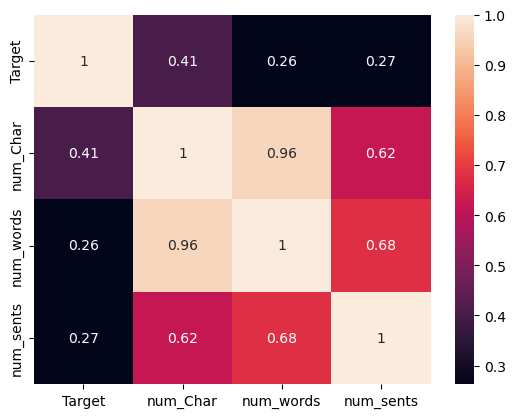

In [ ]:
corr=df[df.columns[df.dtypes!='object']].corr()
sns.heatmap(corr,annot=True)


In [24]:
df.drop(columns=['num_words','num_sents'],inplace=True,axis=1)

In [26]:
df=df[['Text','num_Char','Target']]

In [27]:
df.to_csv('cleaned_data.csv',index=False)